In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import datetime

In [185]:
df = pd.read_csv("../datasets/googleplaystore.csv")

In [186]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [188]:
# Rating
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [189]:
# Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [190]:
# Installs
df["Installs"] = (
    df["Installs"]
      .astype(str)
      .str.replace("+", "", regex=False)
      .str.replace(",", "", regex=False)
)


In [191]:
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [192]:
# Size
df["Size"] = (
    df["Size"]
      .astype(str)
      .str.replace("M", "", regex=False)
)

In [193]:
df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

In [194]:
# Date
df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

In [195]:
filtered_df = df[
    (df["Rating"] >= 4.2) &
    (df["Reviews"] > 1000) &
    (df["Size"] >= 20) &
    (df["Size"] <= 80)
]

In [196]:
filtered_df = filtered_df[
    ~filtered_df["App"].str.contains(r"\d", regex=True, na=False)
]

In [197]:
filtered_df = filtered_df[
    filtered_df["Category"].str.startswith(("T", "P"), na=False)
]

In [198]:
filtered_df.shape

(139, 13)

In [199]:
filtered_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2802,"Shutterfly: Free Prints, Photo Books, Cards, G...",PHOTOGRAPHY,4.6,98716.0,59.0,5000000.0,Free,0,Everyone,Photography,2018-08-01,5.13.1,5.0 and up
2803,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,1000000.0,Free,0,Everyone,Photography,2018-08-02,2.18.2,4.1 and up
2811,"Face Filter, Selfie Editor - Sweet Camera",PHOTOGRAPHY,4.7,142634.0,22.0,10000000.0,Free,0,Everyone,Photography,2018-07-06,1.5.1,4.4 and up
2822,Makeup Editor -Beauty Photo Editor & Selfie Ca...,PHOTOGRAPHY,4.5,3378.0,30.0,1000000.0,Free,0,Mature 17+,Photography,2018-07-25,1.7,4.1 and up
2823,Makeup Photo Editor: Makeup Camera & Makeup Ed...,PHOTOGRAPHY,4.4,10525.0,25.0,1000000.0,Free,0,Everyone,Photography,2018-07-27,8.9.9,4.0 and up


In [200]:
filtered_df["Month"] = filtered_df["Last Updated"].dt.to_period("M").astype(str)

In [201]:
pivot_df = filtered_df.pivot_table(
    index="Month",
    columns="Category",
    values="Installs",
    aggfunc="sum",
    fill_value=0
)

pivot_df = pivot_df.sort_index()

In [202]:
print(pivot_df.columns.tolist())

['PARENTING', 'PERSONALIZATION', 'PHOTOGRAPHY', 'PRODUCTIVITY', 'TOOLS', 'TRAVEL_AND_LOCAL']


In [203]:
pivot_df.rename(columns={
    "TRAVEL_AND_LOCAL": "Voyage et Local",   # French
    "PRODUCTIVITY": "Productividad",         # Spanish
    "PHOTOGRAPHY": "写真"                     # Japanese
}, inplace=True)

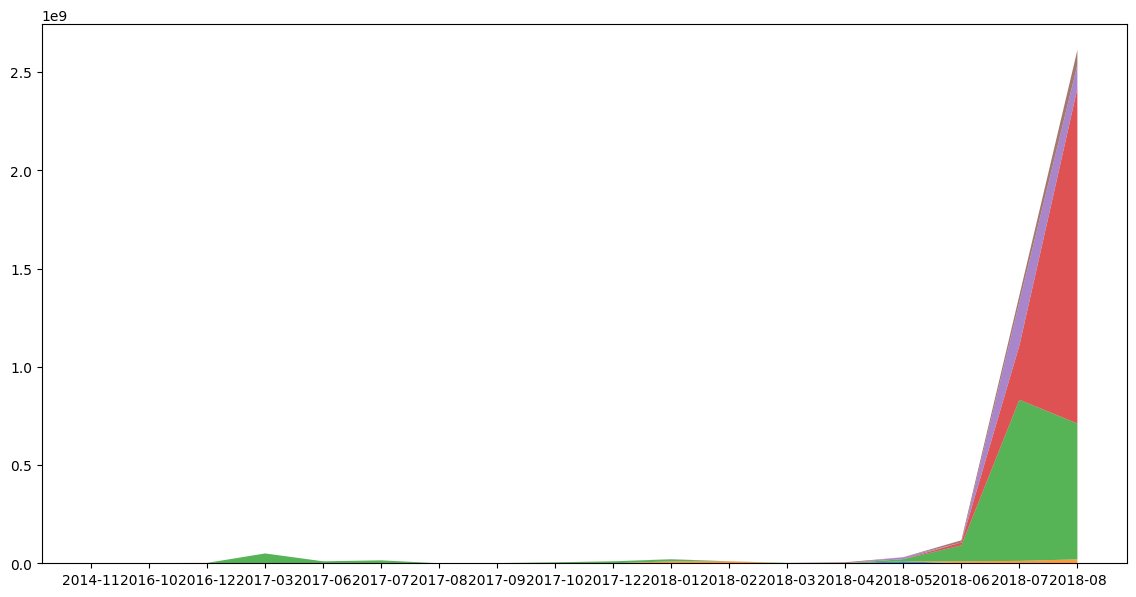

In [204]:
plt.figure(figsize=(14,7))

plt.stackplot(
    pivot_df.index,
    pivot_df.T.values,
    labels=pivot_df.columns,
    alpha=0.8
)

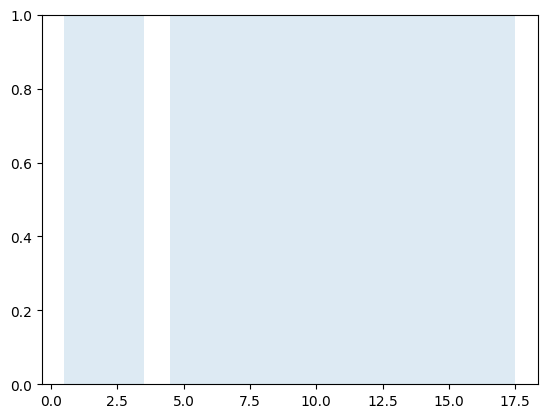

In [205]:
growth = pivot_df.pct_change()

for i in range(1, len(growth)):
    if (growth.iloc[i] > 0.25).any():
        plt.axvspan(i - 0.5, i + 0.5, alpha=0.15)

C:\Users\sathwika\AppData\Local\Temp\ipykernel_26000\631053775.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Category")


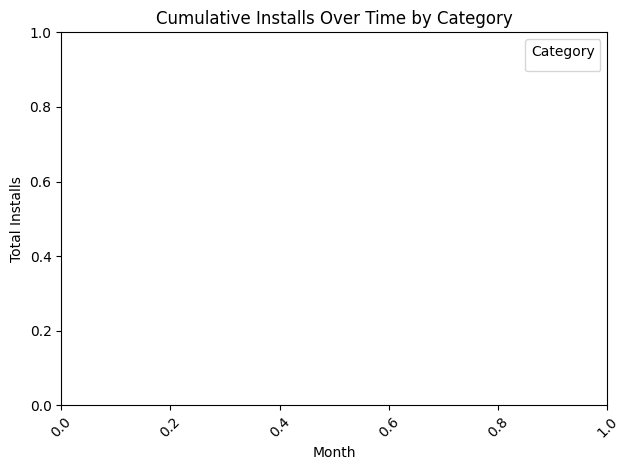

In [206]:
plt.title("Cumulative Installs Over Time by Category")

plt.xlabel("Month")
plt.ylabel("Total Installs")

plt.xticks(rotation=45)

plt.legend(title="Category")

plt.tight_layout()

plt.savefig("stacked_area_chart.png", dpi=300)

plt.show()

In [207]:
print(pivot_df.columns.tolist())

['PARENTING', 'PERSONALIZATION', '写真', 'Productividad', 'TOOLS', 'Voyage et Local']


C:\Users\sathwika\AppData\Local\Temp\ipykernel_26000\1760797742.py:21: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sathwika\AppData\Local\Temp\ipykernel_26000\1760797742.py:21: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sathwika\AppData\Local\Temp\ipykernel_26000\1760797742.py:22: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  plt.savefig("stacked_area_chart.png", dpi=300)
C:\Users\sathwika\AppData\Local\Temp\ipykernel_26000\1760797742.py:22: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.savefig("stacked_area_chart.png", dpi=300)
C:\Users\sathwika\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20889 (\N{CJK U

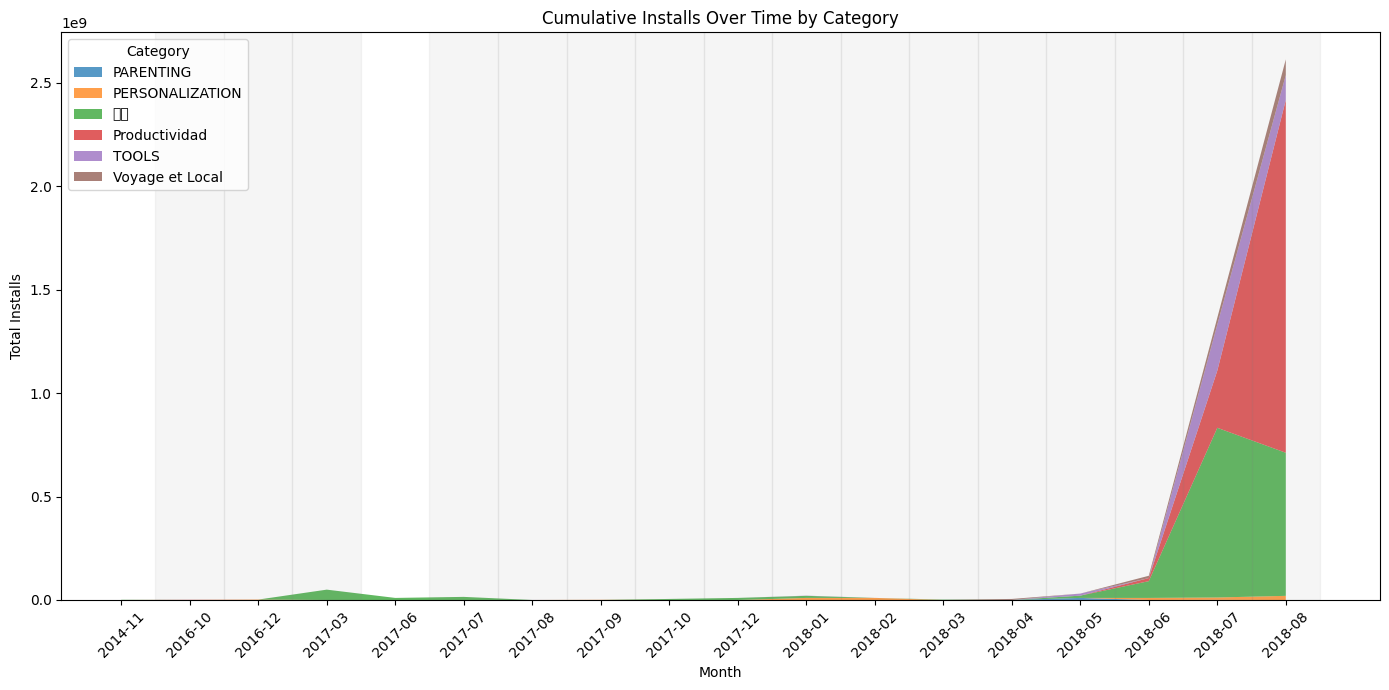

In [208]:
fig, ax = plt.subplots(figsize=(14,7))

collections = ax.stackplot(
    pivot_df.index,
    pivot_df.T.values,
    labels=pivot_df.columns,
    alpha=0.75
)

growth = pivot_df.pct_change()

for i in range(1, len(growth)):
    if (growth.iloc[i] > 0.25).any():
        ax.axvspan(i-0.5, i+0.5, color='gray', alpha=0.08)

plt.title("Cumulative Installs Over Time by Category")
plt.xlabel("Month")
plt.ylabel("Total Installs")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()
plt.savefig("stacked_area_chart.png", dpi=300)
plt.show()

C:\Users\sathwika\AppData\Local\Temp\ipykernel_26000\2970830863.py:54: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sathwika\AppData\Local\Temp\ipykernel_26000\2970830863.py:54: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


'current_hour = datetime.now().hour\nif 16 <= current_hour < 18:\n    plt.savefig(\n        "stacked_area_chart.png",\n        dpi=300,\n        bbox_inches="tight"\n    )\n    plt.show()\nelse:\n    plt.close()\n    print("Chart is available only between 4:00 PM IST and 6:00 PM IST.")'

C:\Users\sathwika\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\events.py:100: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\sathwika\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\events.py:100: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\sathwika\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sathwika\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Py

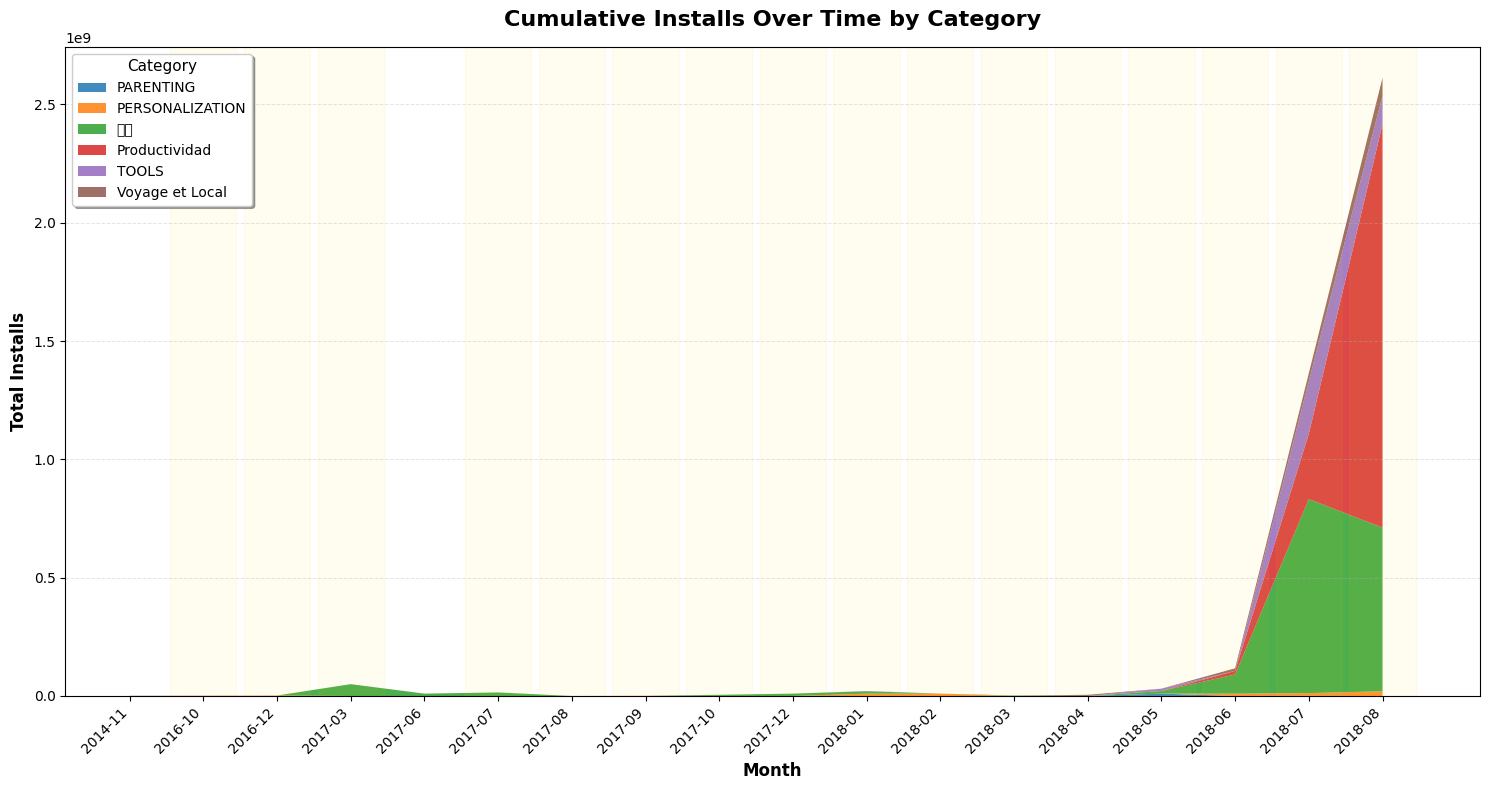

In [209]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.stackplot(
    pivot_df.index,
    pivot_df.T.values,
    labels=pivot_df.columns,
    alpha=0.85
)
growth = pivot_df.pct_change()
for i in range(1, len(growth)):
    if (growth.iloc[i] > 0.25).any():
        ax.axvspan(
            i - 0.45,
            i + 0.45,
            color="gold",
            alpha=0.06
        )
ax.set_title(
    "Cumulative Installs Over Time by Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel(
    "Month",
    fontsize=12,
    fontweight="bold"
)
ax.set_ylabel(
    "Total Installs",
    fontsize=12,
    fontweight="bold"
)
plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)
plt.yticks(fontsize=10)
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35
)
ax.legend(
    title="Category",
    loc="upper left",
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=True
)
plt.tight_layout()
"""current_hour = datetime.now().hour
if 16 <= current_hour < 18:
    plt.savefig(
        "stacked_area_chart.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
else:
    plt.close()
    print("Chart is available only between 4:00 PM IST and 6:00 PM IST.")"""

In [211]:
fig, ax = plt.subplots(figsize=(15, 8), facecolor="white")
# Stacked Area Chart
ax.stackplot(
    pivot_df.index,
    pivot_df.T.values,
    labels=pivot_df.columns,
    alpha=0.9
)
# Highlight months with >25% growth
growth = pivot_df.pct_change()
for i in range(1, len(growth)):
    if (growth.iloc[i] > 0.25).any():
        ax.axvspan(
            i - 0.45,
            i + 0.45,
            color="lightgray",
            alpha=0.18
        )

# Title
ax.set_title(
    "Cumulative App Installs by Category Over Time",
    fontsize=18,
    fontweight="bold",
    pad=20
)
# Axis Labels
ax.set_xlabel(
    "Month",
    fontsize=13,
    fontweight="bold"
)
ax.set_ylabel(
    "Total Installs",
    fontsize=13,
    fontweight="bold"
)
# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)
# Better x-axis labels
plt.xticks(
    rotation=40,
    ha="right",
    fontsize=10
)
plt.yticks(fontsize=10)
# Cleaner Legend
ax.legend(
    title="Category",
    loc="upper left",
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="gray"
)
# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# Time Restriction
current_hour = datetime.now().hour
if 16 <= current_hour < 18:
    plt.savefig(
        "stacked_area_chart.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
else:
    plt.close()
    print("Chart is available only between 4:00 PM IST and 6:00 PM IST.")



Chart is available only between 4:00 PM IST and 6:00 PM IST.


C:\Users\sathwika\AppData\Local\Temp\ipykernel_26000\4122277533.py:66: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sathwika\AppData\Local\Temp\ipykernel_26000\4122277533.py:66: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
